In [112]:
# changes implemented:
# instead of picking two pairs of stocks we think are similar, we screen a large number of stocks, which pick for us.
# instead of doing a ratio / difference for the spread, we use hedge ratio - ols regression

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams["figure.figsize"] = (12, 5) # set default size for plots

from utils import compute_zscore, generate_signals, backtest, sharpe_ratio



In [113]:
# make wider universe of stock pairs
# group them by sector - more likely to be similar

UNIVERSE = {
    "beverages": ["KO", "PEP","BUD", "DEO", "STZ", "MNST", "KDP", "TAP", "SAM", "BF-B" ],
    "oil_majors": ["XOM", "CVX", "SHEL", "TTE", "BP", "COP", "OXY", "SLB", "EOG", "VLO"],
    "airlines": ["DAL", "UAL", "AAL", "LUV", "ALK", "JBLU", "RYAAY", "CPA", "SKYW", "DLAKY"],
    "banks": ["JPM", "BAC", "WFC", "C", "GS", "MS", "USB", "PNC", "TFC", "HSBC"],
    "casino_and_gaming": ["LVS", "MGM", "WYNN", "CZR", "DKNG", "PENN", "BYD", "RSI"],
    "chips": ["NVDA", "TSM", "AVGO", "AMD", "INTC", "QCOM", "TXN", "MU", "AMAT", "ASML"],
    "drone_unmanned": ["AVAV", "KTOS", "RCAT", "EH", "ONDS", "TXT", "JOBY", "LMT", "NOC", "BA"]
}

START_DATE = "2022-01-01"
END_DATE = "2024-01-01"

all_tickers = [t for tickers in UNIVERSE.values() for t in tickers] # 
raw_data = yf.download(all_tickers, start = START_DATE, end = END_DATE, auto_adjust=True)["Close"]
raw_data = raw_data.dropna()
raw_data.head()

[*********************100%***********************]  68 of 68 completed


Ticker,AAL,ALK,AMAT,AMD,ASML,AVAV,AVGO,BA,BAC,BF-B,...,TSM,TTE,TXN,TXT,UAL,USB,VLO,WFC,WYNN,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,18.750000,54.070000,153.697174,150.240005,762.838989,62.730000,61.219208,207.860001,41.055866,64.820724,...,119.708542,39.915466,166.446060,75.987221,45.490002,46.778572,66.920792,45.086212,84.695396,54.041134
2022-01-04,19.020000,55.450001,152.188370,144.419998,745.334106,63.310001,61.920616,213.630005,42.665031,64.675850,...,123.983833,40.119034,166.620743,77.330994,46.250000,48.003777,68.109306,46.881474,84.425209,56.073853
2022-01-05,18.680000,54.770000,147.748413,136.149994,713.270630,63.380001,59.343826,213.070007,41.944912,65.056122,...,118.091362,40.236477,163.145065,75.967331,45.779999,47.750568,67.840378,46.472652,81.298698,56.771255
2022-01-06,18.570000,54.459999,150.247086,136.229996,729.962280,63.110001,58.792843,211.339996,42.789505,62.683876,...,119.401825,40.792385,163.092667,76.425179,45.770000,49.049290,69.540703,47.663570,81.675049,58.106556
2022-01-07,19.280001,55.860001,144.932587,132.000000,723.247498,62.529999,57.142662,215.500000,43.722988,61.706001,...,114.782646,41.473576,156.700317,77.888405,47.310001,49.825264,70.269455,48.676739,81.588211,58.582840


In [114]:
# generate the candidate pairs

from itertools import combinations

def generate_candidate_pairs(UNIVERSE: dict) -> list:
    all_pairs = []
    for sector, tickers in UNIVERSE.items():
        sector_pairs = list(combinations(tickers, 2))
        all_pairs.extend(sector_pairs)
    return all_pairs

candidate_pairs = generate_candidate_pairs(UNIVERSE)
print(f"{len(candidate_pairs)} candidate pairs generated")

298 candidate pairs generated


In [115]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint

# engle-granger cointegration testing with the generated pairs


def cointegration_test(series_a: pd.Series, series_b: pd.Series) -> tuple:
    test_statistic, p_value, crit_values = coint(series_a, series_b)
    return test_statistic, p_value

# now screen all universe pairs

def screen_pairs(pairs: list, prices: pd.DataFrame):
    # build a list of dicts, convert to dataframe, then sort values
    results = []
 
    for ticker_a, ticker_b in pairs:
        pairs_data = prices[[ticker_a, ticker_b]].dropna()

        series_a = pairs_data[ticker_a]
        series_b = pairs_data[ticker_b]

        test_statistics, p_value = cointegration_test(series_a, series_b)

        results.append({
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "test_statistics": test_statistics, 
            "p_value": p_value
        })

        # convert to dataframe
    df_results = pd.DataFrame(results)

        # sort
    df_results = df_results.sort_values(by="p_value", ascending=True).reset_index(drop=True)

    return df_results

screening_results = screen_pairs(candidate_pairs, raw_data)

significance_threshold = 0.05
significant_pairs = screening_results[screening_results["p_value"] < significance_threshold]

print(f"{len(significant_pairs)} of {len(screening_results)} candidate pairs pass at p < {significance_threshold}")
print(significant_pairs)
    

20 of 298 candidate pairs pass at p < 0.05
   ticker_a ticker_b  test_statistics   p_value
0       SAM     BF-B        -4.557746  0.000983
1       KDP      TAP        -4.021013  0.006701
2       PNC      TFC        -3.890659  0.010218
3       AAL      ALK        -3.826488  0.012493
4       EOG      VLO        -3.552647  0.028005
5       TXN       MU        -3.542838  0.028782
6       LMT       BA        -3.530100  0.029819
7        KO      DEO        -3.522397  0.030461
8       LVS     WYNN        -3.495503  0.032796
9      SHEL      TTE        -3.495437  0.032802
10      TXN     AMAT        -3.452175  0.036877
11      JPM     HSBC        -3.441492  0.037947
12      TXN     ASML        -3.428910  0.039239
13      MGM      BYD        -3.425770  0.039568
14      STZ      TAP        -3.413979  0.040821
15       KO      SAM        -3.411117  0.041131
16      COP      EOG        -3.407070  0.041571
17     NVDA     AMAT        -3.346059  0.048705
18      USB      PNC        -3.344416  0.0489

Hedge ratio (beta): 1.1062
Intercept (alpha): 288.3010


<Axes: title={'center': 'OLS-residual spread (SAM ~ BF-B)'}, xlabel='Date'>

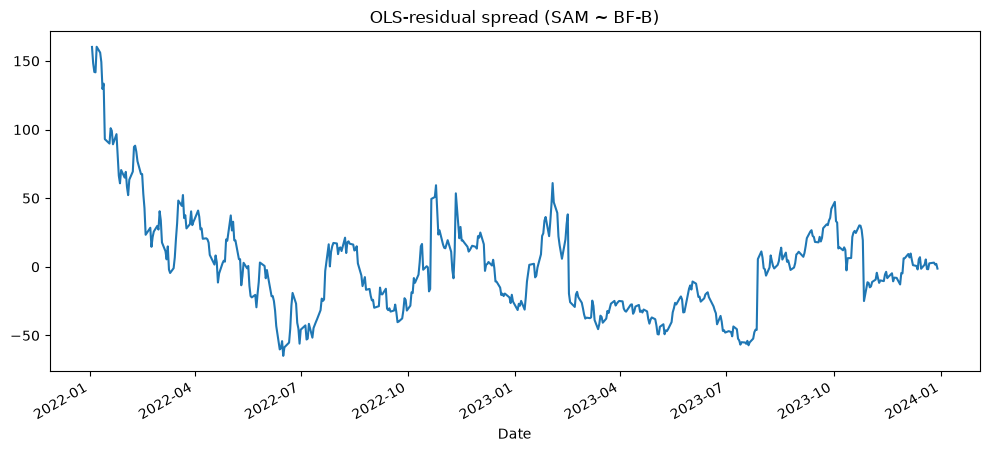

In [117]:
TICKER_A = "SAM"
TICKER_B = "BF-B"
df = raw_data[[TICKER_A, TICKER_B]].dropna()

SERIES_A = df[TICKER_A]
SERIES_B = df[TICKER_B]

# estimate ols hedge ratio
# ols regression simple formula is series_a = alpha + beta * series_b + residual
# beta is the hedge ratio, residual is the spread

def estimate_hedge_ratio(SERIES_A: pd.Series, SERIES_B: pd.Series) -> tuple:
    model = sm.OLS(SERIES_A, sm.add_constant(SERIES_B)).fit()
    alpha = model.params.iloc[0]
    beta = model.params.iloc[1]
    spread = model.resid
    return alpha, beta, spread

alpha, beta, spread = estimate_hedge_ratio(SERIES_A, SERIES_B)
print(f"Hedge ratio (beta): {beta:.4f}")
print(f"Intercept (alpha): {alpha:.4f}")
spread.plot(title=f"OLS-residual spread ({TICKER_A} ~ {TICKER_B})")

In [119]:
z_score = compute_zscore(spread, window = 30)
positions = generate_signals(z_score, entry_threshold=2.0, exit_threshold=0.5)
daily_pnl = backtest(spread, positions)
cumulative_pnl = daily_pnl.cumsum()

sr = sharpe_ratio(daily_pnl.dropna())
print(f"Cointegration-based Sharpe ({TICKER_A}/{TICKER_B}): {sr:.2f}")
print(f"Total P&L (spread units): {cumulative_pnl.iloc[-1]:.2f}")
print(f"Number of trades: {(positions.diff() != 0).sum()}")

Cointegration-based Sharpe (SAM/BF-B): 1.14
Total P&L (spread units): 234.95
Number of trades: 31
